<div style="font-family: 'Helvetica Neue', Arial, sans-serif; background:#0F2E2B; padding: 40px 44px; border-radius: 14px; margin-bottom: 8px; position:relative; overflow:hidden;">
  <div style="font-size:150px; font-weight:900; color:rgba(255,255,255,0.04); position:absolute; top:-30px; right:24px; line-height:1; letter-spacing:-0.05em;">05</div>
  <div style="font-size:10px; color:#5FCDAA; letter-spacing:0.3em; text-transform:uppercase; margin-bottom:18px;">NOVA IMS &middot; 2025/2026</div>
  <div style="font-size:38px; font-weight:800; color:#F5F3EC; letter-spacing:-0.02em; line-height:1.1; margin-bottom:8px;">Home Credit <span style="color:#5FCDAA;">Default Risk.</span></div>
  <div style="font-size:12px; color:#E08A6D; font-weight:500; margin-bottom:28px; letter-spacing:0.05em;">Notebook 5 &mdash; Data Drift &amp; Model Serving</div>
  <div style="display:flex; gap:56px;">
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Group 1</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">Alexandra Varela, 20250514<br>Francisca Fernandes, 20250406<br>Mariana Melo, 20250414<br>Rui Ferreira, 20250473<br>Tiago Antunes, 20250357</div>
    </div>
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Course</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">MLOps<br>MSc Data Science &amp; Advanced Analytics<br>Prof. Nuno Rosa<br>Spring 2026</div>
    </div>
    <div>
      <div style="font-size:9px; color:#5FCDAA; letter-spacing:0.2em; text-transform:uppercase; margin-bottom:8px;">Parts</div>
      <div style="font-size:11px; color:#C5D8D2; line-height:1.95;">D &mdash; Data Drift Detection<br>E &mdash; Model Predict &amp; Serving</div>
    </div>
  </div>
</div>


## Table of Contents

1. [Setup &amp; Imports](#setup)
2. [Load Artefacts](#artefacts)
3. [D1 — PSI per Feature](#d1-psi)
4. [D2 — Drifted Features: distribution comparison](#d2-drift-dist)
5. [D3 — Evidently DataDriftPreset Report](#d3-evidently)
6. [D4 — Alert Decision](#d4-alerts)
7. [E1 — Batch Scoring with the Kedro Pipeline](#e1-batch)
8. [E2 — Serving-time Evaluation](#e2-metrics)
9. [E3 — In-process API Call (`score_features`)](#e3-inproc)
10. [E4 — Live FastAPI Call (HTTP)](#e4-live)
11. [E5 — Docker](#e5-docker)
12. [Summary](#summary)


## About This Notebook

This notebook walks through **Parts D and E** of the Home Credit Default Risk MLOps pipeline:

- **Part D &mdash; Data Drift Detection.** Comparing the feature distributions of the training reference against a current (validation) batch using two complementary measures: the Population Stability Index (Siddiqi, *Intelligent Credit Scoring*) and Evidently's `DataDriftPreset` (KS / Wasserstein / chi&sup2; per feature, plus a dataset-level drift share). The output is an alert payload a downstream job (Slack / PagerDuty / email) would consume in production.
- **Part E &mdash; Model Predict &amp; Serving.** The trained calibrated LightGBM produces batch predictions through the Kedro `model_predict` pipeline, and an online FastAPI app exposes two scoring endpoints. The same `score_features` primitive is reused by both, so batch and online stay in lockstep. A Dockerfile ships the model + API as a self-contained image.

All logic shown here lives under `src/home_credit_mlops/pipelines/data_drifts/`, `src/home_credit_mlops/pipelines/model_predict/`, and `app/`.


<a id="setup"></a>
## 1. Setup &amp; Imports

In [2]:
# Standard library
import json
import os
import pickle
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import IFrame, display, Markdown
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

# Local
from home_credit_mlops.pipelines.model_predict.nodes import score_features

# Project paths — every artefact lives under data/ as produced by `kedro run`
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REPORTING = PROJECT_ROOT / "data" / "08_reporting"
MODEL_DIR = PROJECT_ROOT / "data" / "06_models"
MODEL_INPUT = PROJECT_ROOT / "data" / "05_model_input"
MODEL_OUTPUT = PROJECT_ROOT / "data" / "07_model_output"

# Plotting style — matches the rest of the notebooks in this project
PALETTE = {"bg": "#0F2E2B", "accent": "#5FCDAA", "warning": "#E08A6D", "text": "#F5F3EC", "muted": "#C5D8D2"}
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.figsize": (10, 5), "axes.titleweight": "bold"})


<a id="artefacts"></a>
## 2. Load Artefacts

Every output below comes from a `kedro run` of the upstream pipelines, so this notebook is a pure inspection layer. If any of the files are missing, run:

```bash
$env:MPLBACKEND="Agg"
kedro run    # or each pipeline separately
```

In [3]:
psi = pd.read_csv(REPORTING / "drift_psi_metrics.csv")
alerts = json.loads((REPORTING / "drift_alerts.json").read_text())
metrics = json.loads((REPORTING / "serving_metrics.json").read_text())
predictions = pd.read_csv(MODEL_OUTPUT / "predictions.csv")
X_val = pd.read_csv(MODEL_INPUT / "X_val.csv")
X_train = pd.read_csv(MODEL_INPUT / "X_train.csv")
y_val = pd.read_csv(MODEL_INPUT / "y_val.csv").iloc[:, 0]

print(f"PSI rows           : {len(psi):>6}")
print(f"Drift alert status : {alerts['status']:>6}")
print(f"Predictions rows   : {len(predictions):>6}")
print(f"Reference (X_train): {len(X_train):>6}")
print(f"Current   (X_val)  : {len(X_val):>6}")


PSI rows           :     50
Drift alert status : critical
Predictions rows   :  61503
Reference (X_train): 246008
Current   (X_val)  :  61503


<a id="d1-psi"></a>
## 3. D1 — Population Stability Index per Feature

PSI quantifies how much the distribution of each feature has shifted between the training reference and the current batch. Industry-standard thresholds (Siddiqi):

| PSI band | Interpretation |
|---|---|
| `< 0.10` | No significant change |
| `0.10 – 0.25` | Small to moderate shift &mdash; investigate |
| `≥ 0.25` | Major shift &mdash; model likely degraded |

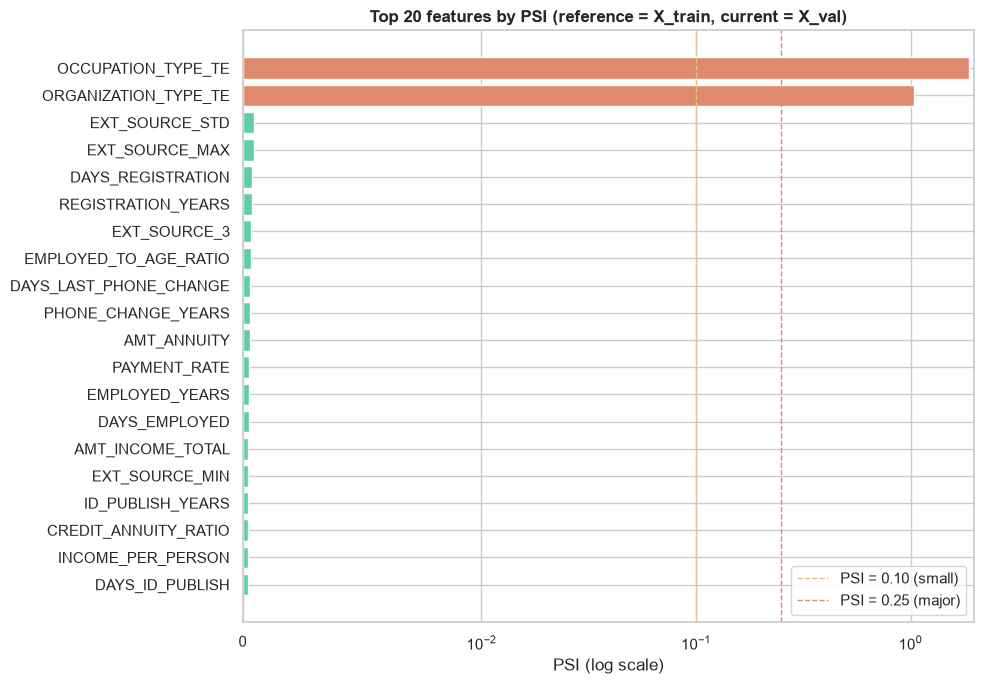

In [4]:
top_n = 20
psi_top = psi.head(top_n).iloc[::-1]   # reverse so the highest PSI sits at the top of the barh

fig, ax = plt.subplots(figsize=(10, 7))
colors = psi_top["drift_level"].map({"none": PALETTE["accent"], "small": "#E5C77B", "major": PALETTE["warning"], "undefined": "#888888"})
ax.barh(psi_top["feature"], psi_top["psi"], color=colors)
ax.axvline(0.10, color="#E5C77B", linestyle="--", linewidth=1, label="PSI = 0.10 (small)")
ax.axvline(0.25, color=PALETTE["warning"], linestyle="--", linewidth=1, label="PSI = 0.25 (major)")
ax.set_xlabel("PSI (log scale)")
ax.set_xscale("symlog", linthresh=0.01)
ax.set_title(f"Top {top_n} features by PSI (reference = X_train, current = X_val)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()


In [5]:
# Drift level counts
psi.groupby("drift_level").size().rename("count").to_frame()


,count
drift_level,
major,2
none,48


<a id="d2-drift-dist"></a>
## 4. D2 — Drifted Features: Distribution Comparison

The two features flagged at "major" level are `OCCUPATION_TYPE_TE` and `ORGANIZATION_TYPE_TE` — both target-encoded. Their high PSI is *expected* given how target encoding is fitted: the encoder learns category means on the train fold via 5-fold out-of-fold smoothing, then re-fits on the full train and applies to val. Different categories appear at different frequencies in val vs train, which inflates PSI even when the underlying class signal is preserved. This is a good real-world demonstration of why PSI for engineered features must be interpreted carefully.

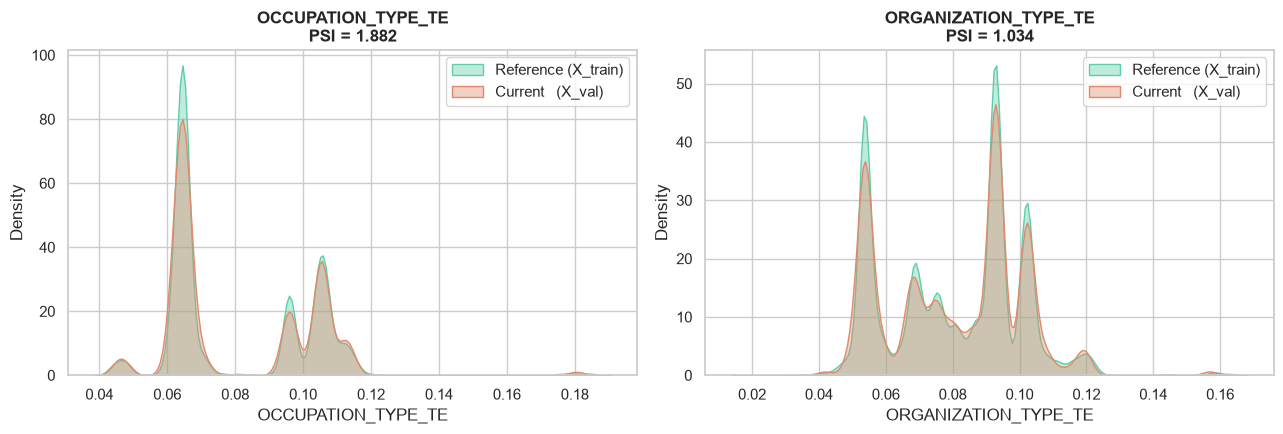

In [6]:
drifted = psi[psi["drift_level"] == "major"]["feature"].tolist()

fig, axes = plt.subplots(1, len(drifted), figsize=(6.5 * len(drifted), 4.5))
if len(drifted) == 1:
    axes = [axes]
for ax, col in zip(axes, drifted):
    sns.kdeplot(X_train[col], label="Reference (X_train)", color=PALETTE["accent"], fill=True, alpha=0.4, ax=ax)
    sns.kdeplot(X_val[col],   label="Current   (X_val)",   color=PALETTE["warning"], fill=True, alpha=0.4, ax=ax)
    psi_val = psi.loc[psi["feature"] == col, "psi"].iloc[0]
    ax.set_title(f"{col}\nPSI = {psi_val:.3f}")
    ax.legend()
plt.tight_layout()
plt.show()


<a id="d3-evidently"></a>
## 5. D3 — Evidently DataDriftPreset Report

The Evidently report adds statistical tests on top of PSI &mdash; Kolmogorov-Smirnov for continuous features, chi&sup2; for categoricals &mdash; and renders an interactive HTML dashboard. The full HTML lives at `data/08_reporting/drift_report.html`; the embed below is a preview.

In [7]:
html_path = REPORTING / "drift_report.html"
print(f"HTML size: {html_path.stat().st_size / 1e6:.1f} MB")
# Relative path works when the notebook is opened from the notebooks/ folder in JupyterLab
IFrame(src="../data/08_reporting/drift_report.html", width="100%", height=500)


HTML size: 9.0 MB


<a id="d4-alerts"></a>
## 6. D4 — Alert Decision

`raise_drift_alerts` turns the per-feature PSI table into a single status (`ok` / `warning` / `critical`) that downstream alerting can consume. Rule:

- `critical` if any feature has PSI ≥ 0.25 **or** if more than 30% of features have PSI ≥ 0.10.
- `warning` if at least one feature drifted at the small level.
- `ok` otherwise.

The alert payload is JSON-serialisable so it can be POSTed to Slack/PagerDuty without further marshalling.

In [8]:
print(json.dumps(alerts, indent=2))

{
  "status": "critical",
  "reason": "2 feature(s) with PSI \u2265 0.25",
  "drifted_features_count": 2,
  "major_drift_features_count": 2,
  "drifted_share": 0.04,
  "evidently_dataset_drift_share": 0.0,
  "drifted_features": [
    {
      "feature": "OCCUPATION_TYPE_TE",
      "psi": 1.8818461966669724,
      "drift_level": "major"
    },
    {
      "feature": "ORGANIZATION_TYPE_TE",
      "psi": 1.0336447678895444,
      "drift_level": "major"
    }
  ],
  "generated_at": "2026-06-29T13:32:50.769802Z"
}


<a id="e1-batch"></a>
## 7. E1 — Batch Scoring with the Kedro Pipeline

The `model_predict` pipeline loads `production_model.pkl` and scores `X_val_data` end-to-end, producing `data/07_model_output/predictions.csv`. The distribution of predicted probabilities tells us whether the model is confident or hugging the prior.

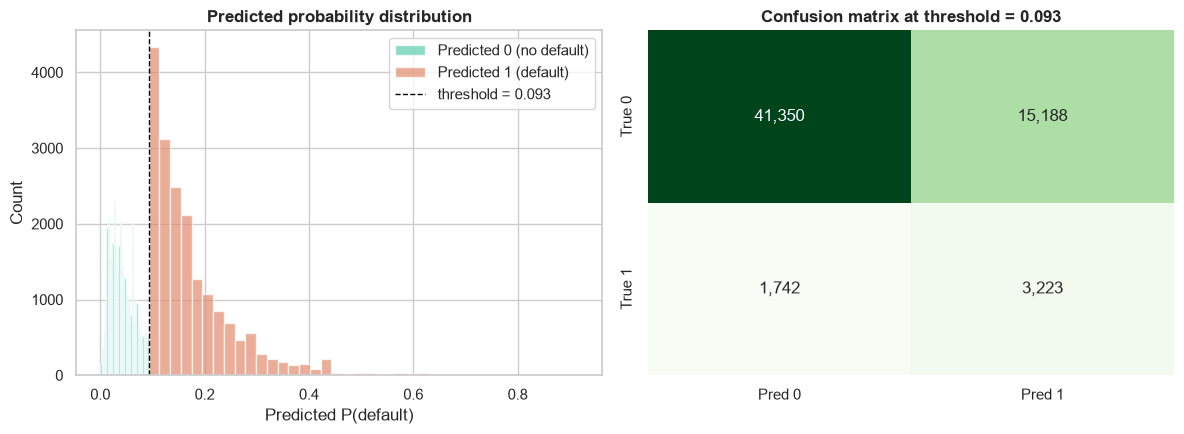

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Histogram of predicted probabilities, split by predicted class
axes[0].hist(predictions.loc[predictions["predicted_class"] == 0, "probability"], bins=40, alpha=0.7, color=PALETTE["accent"], label="Predicted 0 (no default)")
axes[0].hist(predictions.loc[predictions["predicted_class"] == 1, "probability"], bins=40, alpha=0.7, color=PALETTE["warning"], label="Predicted 1 (default)")
axes[0].axvline(metrics["threshold"], linestyle="--", color="black", linewidth=1, label=f"threshold = {metrics['threshold']:.3f}")
axes[0].set_xlabel("Predicted P(default)")
axes[0].set_ylabel("Count")
axes[0].set_title("Predicted probability distribution")
axes[0].legend()

# Confusion matrix at production threshold
y_pred = predictions["predicted_class"].to_numpy()
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt=",d", cmap="Greens", cbar=False, xticklabels=["Pred 0", "Pred 1"], yticklabels=["True 0", "True 1"], ax=axes[1])
axes[1].set_title(f"Confusion matrix at threshold = {metrics['threshold']:.3f}")

plt.tight_layout()
plt.show()


<a id="e2-metrics"></a>
## 8. E2 — Serving-time Evaluation

`evaluate_predictions` recomputes the same panel of classification metrics the training step reports, but on the predicted batch. This serves as the contract that *serving-time* performance still matches *training-time* performance — a guard against silent skew between the two paths.

In [10]:
# Pretty-print as a dataframe
pd.DataFrame({"metric": list(metrics.keys()), "value": list(metrics.values())}).set_index("metric").style.format("{:.4f}", subset=["value"], na_rep="—")


,value
metric,
roc_auc,0.7600
pr_auc,0.2447
accuracy_at_threshold,0.7247
precision_at_threshold,0.1751
recall_at_threshold,0.6491
f1_at_threshold,0.2758
threshold,0.0925
positive_rate_predicted,0.2994
positive_rate_actual,0.0807


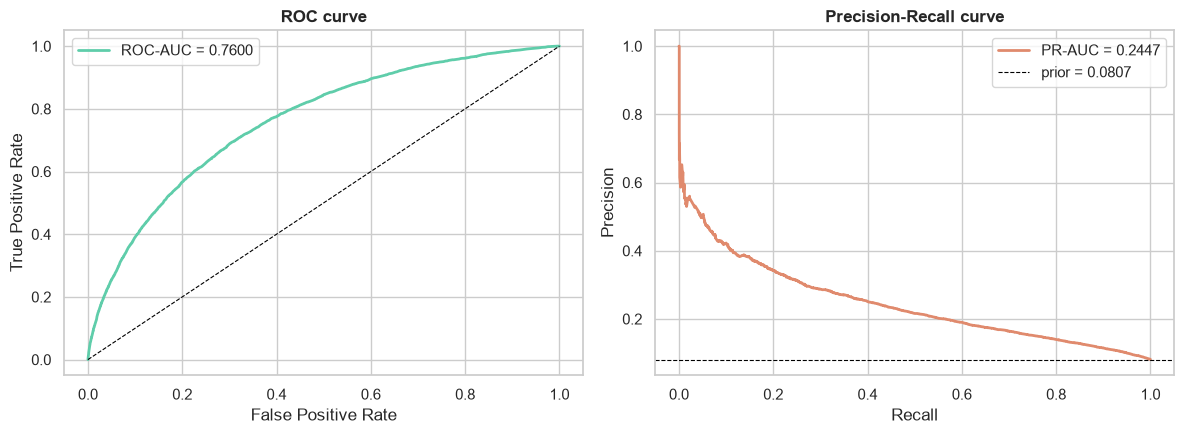

In [11]:
# ROC + PR curves on the validation set
proba = predictions["probability"].to_numpy()
fpr, tpr, _ = roc_curve(y_val, proba)
prec, rec, _ = precision_recall_curve(y_val, proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(fpr, tpr, color=PALETTE["accent"], linewidth=2, label=f"ROC-AUC = {metrics['roc_auc']:.4f}")
axes[0].plot([0, 1], [0, 1], color="black", linewidth=0.8, linestyle="--")
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate"); axes[0].set_title("ROC curve"); axes[0].legend()

axes[1].plot(rec, prec, color=PALETTE["warning"], linewidth=2, label=f"PR-AUC = {metrics['pr_auc']:.4f}")
axes[1].axhline(metrics["positive_rate_actual"], color="black", linestyle="--", linewidth=0.8, label=f"prior = {metrics['positive_rate_actual']:.4f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].set_title("Precision-Recall curve"); axes[1].legend()
plt.tight_layout(); plt.show()


<a id="e3-inproc"></a>
## 9. E3 — In-Process Scoring (`score_features`)

`score_features` is the public utility that powers both the Kedro batch node and the FastAPI `/predict` route. Calling it directly is the fastest way to demonstrate the contract: pass an already-engineered feature vector and the model returns probability + class.

In [12]:
# Load the model and the threshold once
with open(MODEL_DIR / "production_model.pkl", "rb") as fh:
    model = pickle.load(fh)
threshold = json.loads((MODEL_DIR / "decision_threshold.json").read_text())["threshold"]

# Score 5 rows from the validation set
sample = X_val.sample(5, random_state=42).reset_index(drop=True)
preds = score_features(sample, model, decision_threshold=threshold, id_column="SK_ID_CURR")
preds


C:\Users\Rui\PycharmProjects\home-credit-mlops\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Rui\PycharmProjects\home-credit-mlops\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator IsotonicRegression from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\Rui\PycharmProjects\home-credit-mlops\.venv\Lib\site-packages\sklearn\base.py:525: InconsistentVersionWarning: Trying to unpickle estimator C

,SK_ID_CURR,probability,predicted_class
0,116731,0.084214,0
1,209765,0.031576,0
2,131190,0.181649,1
3,218332,0.297367,1
4,425755,0.320547,1


<a id="e4-live"></a>
## 10. E4 — Live FastAPI Call

Start the API in a separate terminal first:

```bash
$env:MPLBACKEND="Agg"
uvicorn app.main:app --port 8000
```

Then run the cell below. The notebook will hit two endpoints &mdash; `/predict` (engineered features, the production contract) and `/predict/raw` (raw application JSON, the convenience endpoint) &mdash; and confirm both return the same probability for a known row.

In [13]:
import requests

API = "http://localhost:8000"

try:
    health = requests.get(f"{API}/health", timeout=2).json()
    print("API /health:", health)

    # /predict — engineered features
    row_features = X_val.iloc[0].to_dict()
    p1 = requests.post(f"{API}/predict", json={"features": row_features}).json()
    print("/predict     ->", p1)

    # /predict/raw — raw application JSON
    raw = pd.read_csv(PROJECT_ROOT / "data" / "01_raw" / "application_train.csv", nrows=1).iloc[0]
    raw = {k: (None if pd.isna(v) else v) for k, v in raw.items()}
    p2 = requests.post(f"{API}/predict/raw", json={"application": raw}).json()
    print("/predict/raw ->", p2)
except requests.exceptions.RequestException as exc:
    print(f"API not running — start it with `uvicorn app.main:app --port 8000` and rerun this cell.\nError: {exc}")


API not running — start it with `uvicorn app.main:app --port 8000` and rerun this cell.
Error: HTTPConnectionPool(host='localhost', port=8000): Max retries exceeded with url: /health (Caused by ConnectTimeoutError(<HTTPConnection(host='localhost', port=8000) at 0x1d802d53cb0>, 'Connection to localhost timed out. (connect timeout=2)'))


<a id="e5-docker"></a>
## 11. E5 — Docker

The serving image is a multi-stage build that bundles the trained model artefact + the cleaning params + the FastAPI app, with `python:3.11-slim` as the runtime base. Stripped of dev tools and notebooks via `.dockerignore`, the final image lands at ~750 MB.

```bash
# Build (once)
docker build -t home-credit-api:latest .

# Run
docker run --rm -p 8000:8000 home-credit-api:latest

# Verify
curl http://localhost:8000/health
```

The container exposes the same `/health`, `/model/schema`, `/predict`, and `/predict/raw` routes as the local API. A `HEALTHCHECK` is wired in the Dockerfile so orchestrators (Kubernetes, ECS, Docker Compose) can readiness-probe the model load on startup.

<a id="summary"></a>
## 12. Summary

| Stage | Artefact | What it answers |
|---|---|---|
| **D1** | `drift_psi_metrics.csv` | Which features drifted, and by how much |
| **D3** | `drift_report.html` | A visual dashboard for stakeholders |
| **D4** | `drift_alerts.json` | A machine-readable alert payload for downstream paging |
| **E1** | `predictions.csv` | Per-applicant probability and class at the production threshold |
| **E2** | `serving_metrics.json` | Confirms serving-time performance matches training |
| **E3-E4** | `app/main.py` + `app/preprocessing.py` | Online scoring contract (engineered features and raw input) |
| **E5** | `Dockerfile` | Reproducible serving artefact |

Two design decisions worth flagging in the report:

1. **Drift "current" set = X_val** — quantifies the validation/train shift baked into the random split. In a real serving deployment, `current` is rotated to a recent serving batch and the same pipeline runs on a daily / hourly schedule.
2. **`/predict` vs `/predict/raw`** — production callers should use `/predict` with engineered features supplied by an upstream feature service (the realistic MLOps contract). `/predict/raw` exists for demos and fall-back scenarios; the fields it cannot derive without the fitted encoder maps (the two target-encoded columns) are reported back as `fallback_features`, so the caller can never confuse a real prediction with a defaulted one.
